In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns
pd.set_option('display.max_columns', None)


In [4]:
file_path = "C:/Users/gjose/DSC630 Course Project/diabetic_data.csv"
df = pd.read_csv(file_path)
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.info()


Shape: (101766, 50)

Columns:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null 

In [9]:
# '?' used as missing value placeholder
(df == '?').sum().sort_values(ascending=False)


weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

In [11]:
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)


In [13]:
df['readmit_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmit_binary'].value_counts()


readmit_binary
0    90409
1    11357
Name: count, dtype: int64

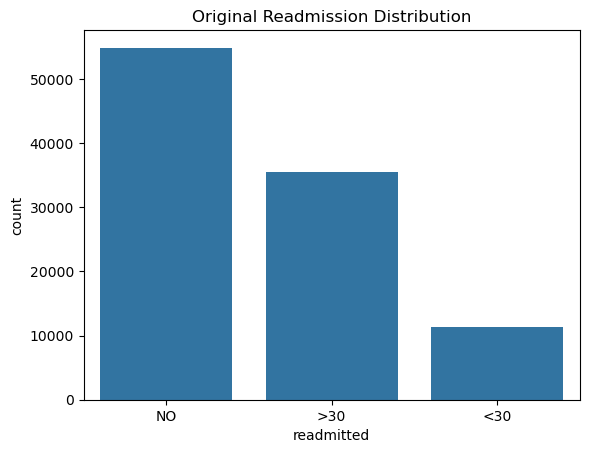

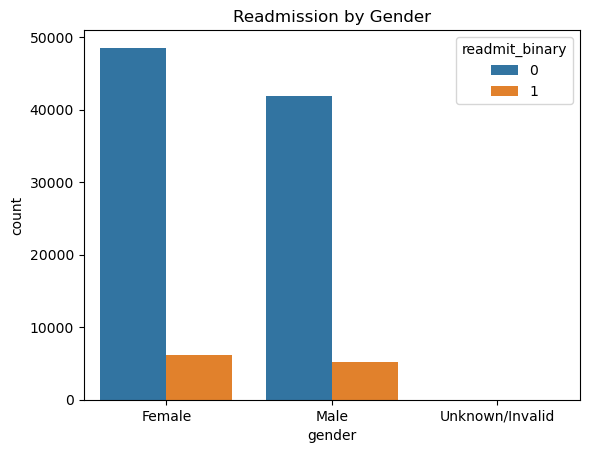

In [15]:
# Readmission counts
sns.countplot(data=df, x='readmitted')
plt.title("Original Readmission Distribution")
plt.show()

# Readmission by gender
sns.countplot(data=df, x='gender', hue='readmit_binary')
plt.title("Readmission by Gender")
plt.show()


In [17]:
df.nunique().sort_values(ascending=False)


diag_3                      790
diag_2                      749
diag_1                      717
num_lab_procedures          118
num_medications              75
medical_specialty            73
number_outpatient            39
number_emergency             33
discharge_disposition_id     26
number_inpatient             21
payer_code                   18
admission_source_id          17
number_diagnoses             16
time_in_hospital             14
weight                       10
age                          10
admission_type_id             8
num_procedures                7
race                          6
glipizide                     4
glyburide-metformin           4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
glyburide                     4
nateglinide                   4
chlorpropamide                4
repaglinide                   4
metformin                     4
glimepir

In [29]:
import pandas as pd
import numpy as np

# Load datasets
data_path = "C:/Users/gjose/DSC630 Course Project/diabetic_data.csv"
ids_mapping_path = "C:/Users/gjose/DSC630 Course Project/IDS_mapping.csv"

df = pd.read_csv(data_path)
ids_mapping = pd.read_csv(ids_mapping_path)

# Drop columns with only one value or too many missing values
df = df.drop(['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr'], axis=1)

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop rows with missing values in key columns
df = df.dropna()

# Convert readmitted column to binary: 1 = readmitted within 30 days, 0 = not
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Simplify age groups to numeric midpoints
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_mapping)

# Drop columns with high cardinality or too specific
df = df.drop(['diag_1', 'diag_2', 'diag_3'], axis=1)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Display the shape and first few rows of the cleaned data
print("Cleaned dataset shape:", df_encoded.shape)
df_encoded.head()


Cleaned dataset shape: (289, 48)


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_Norm,metformin_No,metformin_Steady,metformin_Up,repaglinide_Steady,repaglinide_Up,nateglinide_Steady,chlorpropamide_Steady,glimepiride_Steady,glimepiride_Up,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_Steady,glyburide_Up,pioglitazone_No,pioglitazone_Steady,rosiglitazone_Steady,rosiglitazone_Up,acarbose_Steady,acarbose_Up,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_Steady,change_No,diabetesMed_Yes
162,85,6,3,7,5,47,1,6,0,0,0,5,1,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
460,75,6,1,7,10,72,1,19,0,0,0,5,0,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True
593,55,6,1,7,2,61,0,5,0,0,0,5,0,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True
696,75,6,6,7,11,71,1,20,0,0,0,5,0,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True
771,35,6,1,2,14,43,0,11,0,0,0,3,0,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
